ESERCIZIO

Crea un autoencoder per insegnare a un modello a generare i capi di abbigliamente del feshion mnist
Utilizza il codice visto modificando il numero di neuroni per riuscire a gestire correttamente l'aumento di complessità delle immagini.
Commenta il risultato ottenuto.

Model: "Autoencoder_FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Immagine (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Ricostruzione (Dense)           │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

Inizio fase di addestramento su Fashion MNIST...
Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0421 - val_loss: 0.0228
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0202 - val_loss: 0.0182
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0173 - val_loss: 0.0162
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0156 - val_loss: 0.0150
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0145 - val_loss: 0.0140
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0136 - val_loss: 0.0134
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0131 - val_loss: 0.0127
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0124 - val_loss: 0.0123
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0121 - val_loss: 0.0119
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0116 - val_loss: 0.0116
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0112 - val_loss:

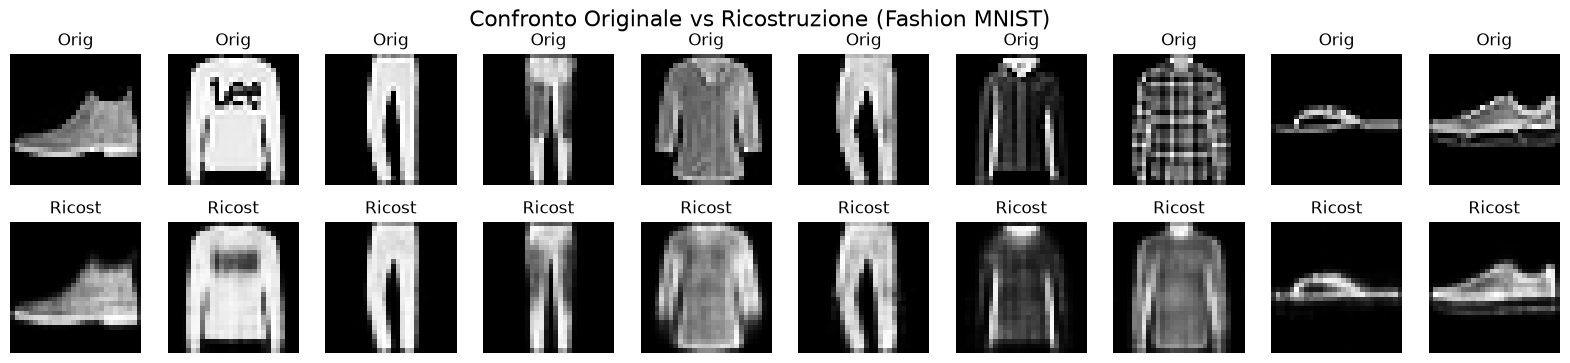

In [1]:
import os

# Configurazione del backend di Keras.
# Impostiamo PyTorch come motore di calcolo numerico.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt


# Carichiamo il dataset Fashion MNIST.
# A differenza del dataset MNIST (cifre), questo contiene immagini di vestiti/accessori
# (t-shirt, pantaloni, scarpe, borse, ecc.) che sono più complessi da ricostruire.
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

# Normalizzazione dei dati: i valori dei pixel vengono portati nell'intervallo [0, 1].
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

#appiattimento (Flattening): trasformiamo ogni immagine 28x28 in un vettore di 784 elementi.
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))


# Per gestire la maggiore complessità del Fashion MNIST rispetto alle cifre,
# aumentiamo la capacità del modello aggiungendo neuroni e potenzialmente strati.

input_dim = 784    # 28*28
latent_dim = 64    # Aumentiamo la dimensione latente da 32 a 64 per catturare più dettagli.

# --- ENCODER ---
inputs = keras.Input(shape=(input_dim,), name="Input_Immagine")

# Aggiungiamo uno strato intermedio con più neuroni (256 invece di 128) per gestire la complessità.
x = layers.Dense(256, activation="relu")(inputs)
# Un secondo strato nell'encoder per raffinare le caratteristiche prima del collo di bottiglia.
x = layers.Dense(128, activation="relu")(x)

# Strato Bottleneck: rappresentazione compressa a 64 dimensioni.
latent = layers.Dense(latent_dim, activation="relu", name="Bottleneck")(x)

# --- DECODER ---
# Ricostruiamo specularmente rispetto all'encoder.
x = layers.Dense(128, activation="relu")(latent)
x = layers.Dense(256, activation="relu")(x)

# Output finale con attivazione sigmoid per riportare i valori tra 0 e 1.
outputs = layers.Dense(input_dim, activation="sigmoid", name="Ricostruzione")(x)

# Creazione del modello
autoencoder = keras.Model(inputs=inputs, outputs=outputs, name="Autoencoder_FashionMNIST")

# Visualizza il riepilogo del modello per confermare l'architettura.
autoencoder.summary()


autoencoder.compile(optimizer="adam", loss="mse")

# Aumentiamo il numero di epoche da 10 a 30 perché il dataset è più difficile da apprendere
# e richiede più iterazioni per convergere a una buona ricostruzione.
print("Inizio fase di addestramento su Fashion MNIST...")
autoencoder.fit(
    x_train, 
    x_train, 
    epochs=30, 
    batch_size=256, 
    validation_data=(x_test, x_test), 
    verbose=1
)


# Ricostruzione delle prime 10 immagini del test set
decoded_imgs = autoencoder.predict(x_test[:10], verbose=0)

# Conversione in numpy per la visualizzazione
decoded_imgs_np = ops.convert_to_numpy(decoded_imgs)
x_test_np = x_test[:10]

# Visualizzazione
plt.figure(figsize=(20, 4))
for i in range(10):
    # Originale
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_np[i].reshape(28, 28), cmap="gray")
    plt.title("Orig")
    plt.axis("off")

    # Ricostruito
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs_np[i].reshape(28, 28), cmap="gray")
    plt.title("Ricost")
    plt.axis("off")

plt.suptitle("Confronto Originale vs Ricostruzione (Fashion MNIST)", fontsize=16)
plt.show()